<a href="https://colab.research.google.com/github/Manmanfr/UIS-Render/blob/main/Segmentacion%20con%20LANGSAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Primero segmentamos el mapa con SAM normal

In [ ]:
import os
import torch
from samgeo import SamGeo
from samgeo.common import split_raster, merge_rasters, raster_to_vector

# 1. Rutas principales
imagen_uis = "/content/drive/MyDrive/Procesamiento_SAM/UIS_Central.tif"
carpeta_base = "/content/drive/MyDrive/Procesamiento_SAM"

# Carpetas temporales para guardar los recortes y las máscaras
tile_dir = os.path.join(carpeta_base, "tiles_entrada")
mask_dir = os.path.join(carpeta_base, "tiles_salida")
salida_tif_final = os.path.join(carpeta_base, "segmentacion_final.tif")
salida_shp = os.path.join(carpeta_base, "poligonos_uis.shp")

os.makedirs(tile_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

# Dividir en mosaicos
split_raster(imagen_uis, out_dir=tile_dir, tile_size=(1500, 1500), overlap=50)

sam = SamGeo(model_type="vit_b", device="cuda")
tiles = [f for f in os.listdir(tile_dir) if f.endswith('.tif')]
print(f"Total de recuadros a procesar: {len(tiles)}")

for i, tile in enumerate(tiles):
    print(f"Segmentando fragmento {i+1}/{len(tiles)}: {tile}")
    in_path = os.path.join(tile_dir, tile)
    out_path = os.path.join(mask_dir, tile)

    sam.generate(in_path, out_path)
    torch.cuda.empty_cache()

print("3. Uniendo los pedazos segmentados...")
merge_rasters(mask_dir, salida_tif_final)

print("4. Vectorizando el mapa completo a Shapefile...")
raster_to_vector(salida_tif_final, salida_shp)


#Ya con el mapa segmentado, usamos langSAM para segmentar cosas de nuestro interes


In [ ]:
import os
import torch
from samgeo.text_sam import LangSAM
from samgeo.common import split_raster, merge_rasters, raster_to_vector

# Rutas
imagen_uis = "/content/drive/MyDrive/Procesamiento_SAM/UIS_Central.tif"
carpeta_base = "/content/drive/MyDrive/Procesamiento_SAM"

# Carpeta con la imagen ya segmentada o si esta carpeta no esta procedemos a segmentar la imagen
tile_dir = os.path.join(carpeta_base, "tiles_entrada")
os.makedirs(tile_dir, exist_ok=True)

if not os.listdir(tile_dir):
    split_raster(imagen_uis, out_dir=tile_dir, tile_size=(1500, 1500), overlap=50)

# Categorias que vamos a buscar
categorias = {
    "edificios": ("building roof", 0.45, 0.45),
    "arboles": ("tree", 0.30, 0.30),
    "caminos": ("asphalt road or paved path", 0.25, 0.25)
}

sam = LangSAM()

tiles = [f for f in os.listdir(tile_dir) if f.endswith('.tif')]
print(f"Total de fragmentos a procesar por categoría: {len(tiles)}")

# Bucle principal
for nombre_capa, (prompt, box_thresh, text_thresh) in categorias.items():
    print(f"PROCESANDO CATEGORÍA: {nombre_capa.upper()}")
    print(f"Prompt: '{prompt}' | Umbrales: Box={box_thresh}, Text={text_thresh}")
    mask_dir_clase = os.path.join(carpeta_base, f"tiles_salida_{nombre_capa}")
    os.makedirs(mask_dir_clase, exist_ok=True)

    salida_tif_final = os.path.join(carpeta_base, f"segmentacion_{nombre_capa}.tif")
    salida_shp = os.path.join(carpeta_base, f"poligonos_{nombre_capa}.shp")

    # Segmentar cada fragmento usando el prompt de la categoría actual
    for i, tile in enumerate(tiles):
        print(f"[{nombre_capa.upper()}] Analizando fragmento {i+1}/{len(tiles)}: {tile}")
        in_path = os.path.join(tile_dir, tile)
        out_path = os.path.join(mask_dir_clase, tile)

        sam.predict(
            image=in_path,
            text_prompt=prompt,
            box_threshold=box_thresh,
            text_threshold=text_thresh,
            output=out_path
        )
        torch.cuda.empty_cache()

    print(f"Uniendo fragmentos de {nombre_capa}...")
    merge_rasters(mask_dir_clase, salida_tif_final)

    print(f"Vectorizando {nombre_capa} a Shapefile...")
    raster_to_vector(salida_tif_final, salida_shp)



#Coordenadas

In [9]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import geopandas as gpd

#Carga de las capas

caminos = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/poligonos_caminos.shp')
caminos['clase'] = 'camino'

uis = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/poligonos_uis.shp')
uis['clase'] = 'zona_uis'

edificios = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/Edificios.gpkg')
edificios['clase'] = 'edificio'

canchas = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/leisure_pitch.gpkg')
canchas['clase'] = 'cancha'

Zona_Verde = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/Zona_verde.gpkg')
Zona_Verde['clase'] = 'zona_verde'

amenity = gpd.read_file('/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/amenity.gpkg')
amenity['clase'] = 'amenity'

# HOMOLOGACIÓN DE COORDENADAS (CRS)
crs_objetivo = "EPSG:4326"

caminos = caminos.to_crs(crs_objetivo)
uis = uis.to_crs(crs_objetivo)
edificios = edificios.to_crs(crs_objetivo)
canchas = canchas.to_crs(crs_objetivo)
Zona_Verde = Zona_Verde.to_crs(crs_objetivo)
amenity = amenity.to_crs(crs_objetivo)

#Borramos lo que este fuera de amenity

caminos = gpd.clip(caminos, amenity)
uis = gpd.clip(uis, amenity)
edificios = gpd.clip(edificios, amenity)
canchas = gpd.clip(canchas, amenity)
Zona_Verde = gpd.clip(Zona_Verde, amenity)

#Unificacion
biblioteca_completa = pd.concat([caminos, uis, edificios, canchas, Zona_Verde], ignore_index=True)

ruta_salida = "/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/clases_uis.geojson"

print("Exportando a Google Drive...")
biblioteca_completa.to_file(ruta_salida, driver="GeoJSON")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Convirtiendo coordenadas a WGS 84...
Recortando elementos fuera de la universidad...
Uniendo todas las capas...
Exportando a Google Drive...
¡Éxito total! Tu biblioteca está lista y guardada en: /content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/clases_uis.geojson


#Visualización

Cargando la biblioteca desde Drive...

--- MUESTRA DE LOS DATOS ---
    clase                                           geometry
0  camino  POLYGON ((-73.12085 7.13916, -73.12085 7.13916...
1  camino  POLYGON ((-73.12082 7.13918, -73.12082 7.13918...
2  camino  POLYGON ((-73.12067 7.13924, -73.12067 7.13924...
3  camino  POLYGON ((-73.12086 7.13921, -73.12086 7.1392,...
4  camino  POLYGON ((-73.12085 7.13921, -73.12085 7.13921...

--- TOTAL DE POLÍGONOS POR CLASE (POST-RECORTE) ---
clase
zona_uis      15073
camino          963
edificio         50
cancha           16
zona_verde       11
Name: count, dtype: int64

Generando visualización...


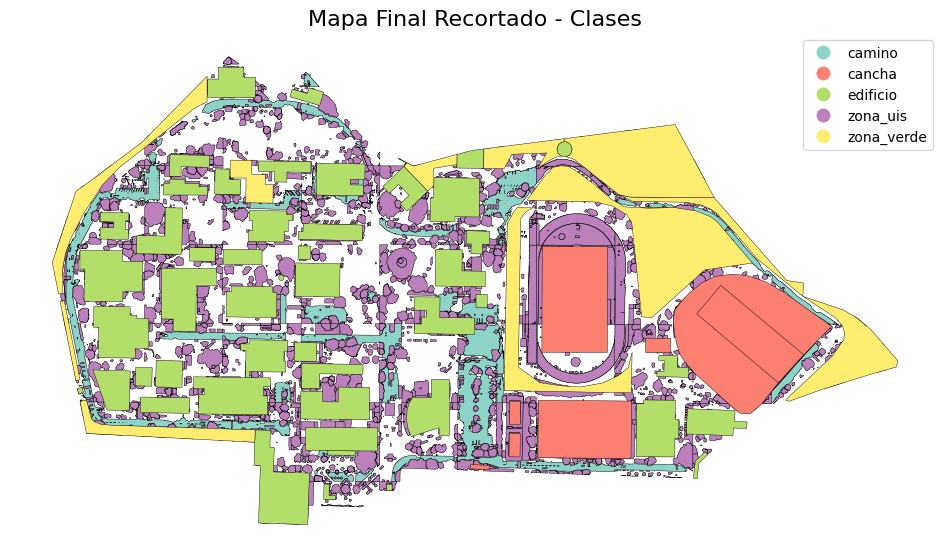

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

ruta_salida = "/content/drive/MyDrive/Procesamiento_SAM/Proyecto sin ruido/clases_uis.geojson"
print("Cargando la biblioteca desde Drive...")

mi_biblioteca = gpd.read_file(ruta_salida)

# Revisamos la estructura básica
print("\n--- MUESTRA DE LOS DATOS ---")
print(mi_biblioteca[['clase', 'geometry']].head())

# Confirmamos cuántos polígonos quedaron de cada clase tras el recorte
print("\n--- TOTAL DE POLÍGONOS POR CLASE (POST-RECORTE) ---")
print(mi_biblioteca['clase'].value_counts())

#Graficación
fig, ax = plt.subplots(figsize=(12, 12))
mi_biblioteca.plot(
    column='clase',
    legend=True,
    ax=ax,
    cmap='Set3',
    edgecolor='black',
    linewidth=0.3
)

ax.set_title("Mapa Final Recortado - Clases", fontsize=16)
ax.set_axis_off()

plt.show()